# Exercise 06 : Scatter Matrix




In [1]:
import pandas as pd
from pandas.plotting import scatter_matrix
import sqlite3
import matplotlib.pyplot as plt

data = sqlite3.connect('../data/checking-logs.sqlite')
user = pd.read_csv('../data/ab-test.csv')

df_views = pd.read_sql_query("SELECT uid, datetime FROM pageviews WHERE uid LIKE 'user_%'", data)
df_commits = pd.read_sql_query("SELECT uid, timestamp FROM checker WHERE uid LIKE 'user_%' AND labname != 'project1'", data)

data.close()

## Подготовка таблицы для построения графика




In [2]:
users = user[user['group'] == 'test']
users = users.groupby('uid')['diff'].mean().reset_index(name='avg_diff')

df_final_views = users.merge(df_views, on='uid', how='inner')
df_final_commits = users.merge(df_commits, on='uid', how='inner')

commits = df_final_commits.groupby('uid')['timestamp'].size().reset_index(name='commits')
views = df_final_views.groupby('uid')['datetime'].size().reset_index(name='pageviews')

df_final = pd.merge(commits, views, on='uid', how='outer').fillna(0)
df_final = df_final.merge(users[['uid', 'avg_diff']], on='uid', how='left')
df_final.drop(columns=['uid'], inplace=True)
df_final

,commits,pageviews,avg_diff
0,62,28,-54.666667
1,5,3,-6.750000
2,118,16,-115.166667
3,65,10,-95.500000
4,79,179,-98.416667
5,60,149,-94.750000
6,18,317,-114.250000


## Отрисовка графика




<Figure size 1000x1000 with 0 Axes>

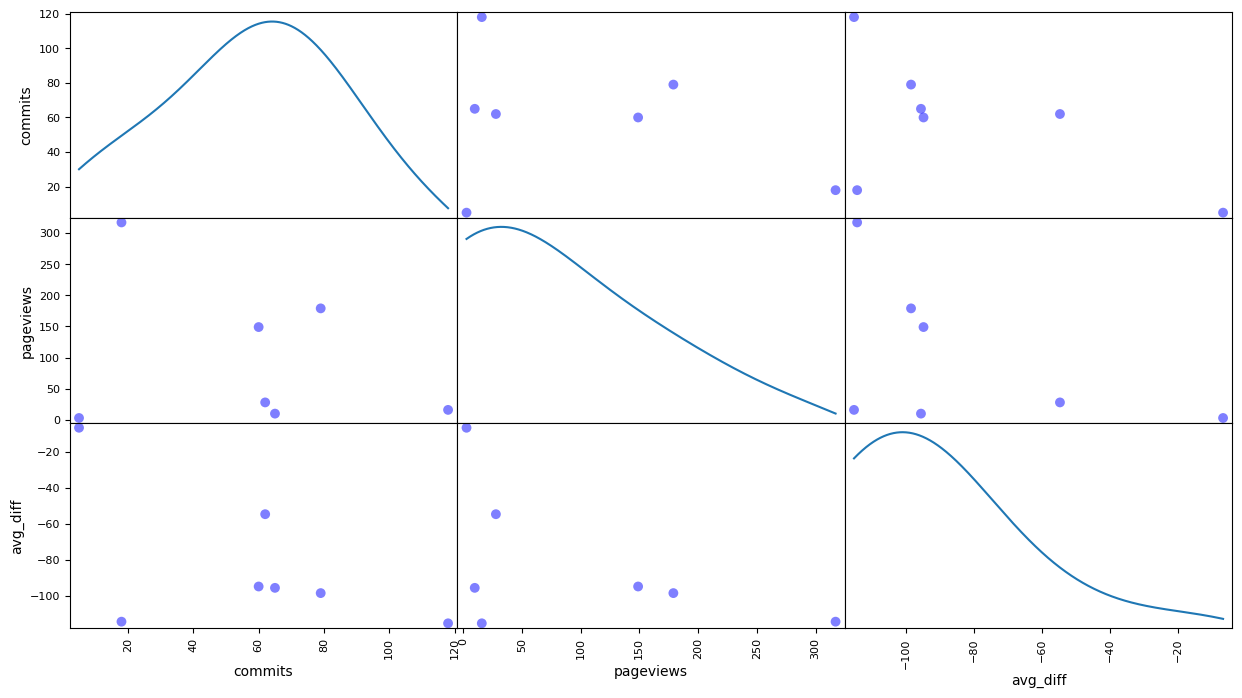

In [3]:
plt.figure(figsize=(10, 10))
scatter_matrix(
    df_final, 
    alpha=0.5, 
    figsize=(15, 8), 
    diagonal='kde', 
    color='blue', 
    s=200, 
    hist_kwds={'linewidth': 3}
)
plt.show()

## Can we say that if a user has a low number of pageviews then they likely have a low number of commits?
#### no
## Can we say that if a user has a low number of pageviews then they likely have a small average difference between the first commit and the lab deadline?
#### yes
## Can we say that there are many users with a low number of commits and a few with a high number of commits?
#### yes
## Can we say that there are many users with a small average difference and a few with a large average difference? 
#### no



